In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import PROCESSED_DATA_DIR, STRESS_WINDOWS, HYPOTHETICAL_SHOCK
from src.data_utils import read_panel
from src.stress import compute_window_metrics

# Load returns
us = read_panel(PROCESSED_DATA_DIR / "us_portfolio.csv")["return"]
india = read_panel(PROCESSED_DATA_DIR / "india_portfolio.csv")["return"]

# Load static VaR
us_static_95 = pd.read_csv(PROCESSED_DATA_DIR / "us_var_static_95.csv", index_col=0, parse_dates=True)
us_static_99 = pd.read_csv(PROCESSED_DATA_DIR / "us_var_static_99.csv", index_col=0, parse_dates=True)
india_static_95 = pd.read_csv(PROCESSED_DATA_DIR / "india_var_static_95.csv", index_col=0, parse_dates=True)
india_static_99 = pd.read_csv(PROCESSED_DATA_DIR / "india_var_static_99.csv", index_col=0, parse_dates=True)

# Load GARCH/GJR
us_garch_95 = pd.read_csv(PROCESSED_DATA_DIR / "us_garch_var_95.csv", index_col=0, parse_dates=True)
us_garch_99 = pd.read_csv(PROCESSED_DATA_DIR / "us_garch_var_99.csv", index_col=0, parse_dates=True)
us_gjr_95 = pd.read_csv(PROCESSED_DATA_DIR / "us_gjr_var_95.csv", index_col=0, parse_dates=True)
us_gjr_99 = pd.read_csv(PROCESSED_DATA_DIR / "us_gjr_var_99.csv", index_col=0, parse_dates=True)
india_garch_95 = pd.read_csv(PROCESSED_DATA_DIR / "india_garch_var_95.csv", index_col=0, parse_dates=True)
india_garch_99 = pd.read_csv(PROCESSED_DATA_DIR / "india_garch_var_99.csv", index_col=0, parse_dates=True)
india_gjr_95 = pd.read_csv(PROCESSED_DATA_DIR / "india_gjr_var_95.csv", index_col=0, parse_dates=True)
india_gjr_99 = pd.read_csv(PROCESSED_DATA_DIR / "india_gjr_var_99.csv", index_col=0, parse_dates=True)

print("Loaded all data.")

Loaded all data.


In [2]:
var_data = {
    "US": {
        "95%": {
            "Historical": us_static_95["historical_var"],
            "Normal": us_static_95["normal_var"],
            "Student-t": us_static_95["student_t_var"],
            "Monte_Carlo": us_static_95["monte_carlo_var"],
            "GARCH": us_garch_95["var"],
            "GJR-GARCH": us_gjr_95["var"],
        },
        "99%": {
            "Historical": us_static_99["historical_var"],
            "Normal": us_static_99["normal_var"],
            "Student-t": us_static_99["student_t_var"],
            "Monte_Carlo": us_static_99["monte_carlo_var"],
            "GARCH": us_garch_99["var"],
            "GJR-GARCH": us_gjr_99["var"],
        },
    },
    "India": {
        "95%": {
            "Historical": india_static_95["historical_var"],
            "Normal": india_static_95["normal_var"],
            "Student-t": india_static_95["student_t_var"],
            "Monte_Carlo": india_static_95["monte_carlo_var"],
            "GARCH": india_garch_95["var"],
            "GJR-GARCH": india_gjr_95["var"],
        },
        "99%": {
            "Historical": india_static_99["historical_var"],
            "Normal": india_static_99["normal_var"],
            "Student-t": india_static_99["student_t_var"],
            "Monte_Carlo": india_static_99["monte_carlo_var"],
            "GARCH": india_garch_99["var"],
            "GJR-GARCH": india_gjr_99["var"],
        },
    },
}

returns_data = {"US": us, "India": india}

print("Data structure built.")

Data structure built.


In [3]:
rows = []

for window_name, (start, end, scope) in STRESS_WINDOWS.items():
    if scope == "US":
        markets = ["US"]
    else:
        markets = ["US", "India"]
    for market in markets:
        for level in ["95%", "99%"]:
            for method, var_series in var_data[market][level].items():
                metrics = compute_window_metrics(
                    returns_data[market], var_series, start, end
                )
                rows.append({
                    "window": window_name,
                    "market": market,
                    "level": level,
                    "method": method,
                    **metrics,
                })

stress_results = pd.DataFrame(rows)
print(f"Computed {len(stress_results)} stress-test rows.")
stress_results.head()

Computed 60 stress-test rows.


,window,market,level,method,n_violations,total_breach,worst_breach_ratio,avg_breach_severity,worst_return
0,COVID_2020,US,95%,Historical,15,0.511632,6.855060,0.034109,-0.126778
1,COVID_2020,US,95%,Normal,15,0.472288,5.828445,0.031486,-0.126778
2,COVID_2020,US,95%,Student-t,16,0.582206,8.092382,0.036388,-0.126778
3,COVID_2020,US,95%,Monte_Carlo,15,0.505928,6.469467,0.033729,-0.126778
4,COVID_2020,US,95%,GARCH,9,0.283588,3.121135,0.031510,-0.126778


In [4]:
view_violations = stress_results.pivot_table(
    index=["window", "market", "level"],
    columns="method",
    values="n_violations",
)
print("Violation counts by method:")
print(view_violations)
print()

view_breach = stress_results.pivot_table(
    index=["window", "market", "level"],
    columns="method",
    values="worst_breach_ratio",
)
print("Worst breach ratio:")
print(view_breach.round(2))

Violation counts by method:
method                         GARCH  GJR-GARCH  Historical  Monte_Carlo  \
window           market level                                              
CHINA-2015       India  95%      3.0        3.0         4.0          4.0   
                        99%      3.0        3.0         2.0          2.0   
                 US     95%      4.0        4.0         8.0          8.0   
                        99%      3.0        3.0         4.0          4.0   
COVID_2020       India  95%      9.0        9.0        12.0         12.0   
                        99%      8.0        8.0         7.0          7.0   
                 US     95%      9.0       11.0        15.0         15.0   
                        99%      7.0        7.0         8.0          7.0   
Volmageddon_2018 US     95%      3.0        3.0         3.0          3.0   
                        99%      3.0        3.0         3.0          3.0   

method                         Normal  Student-t  
window  

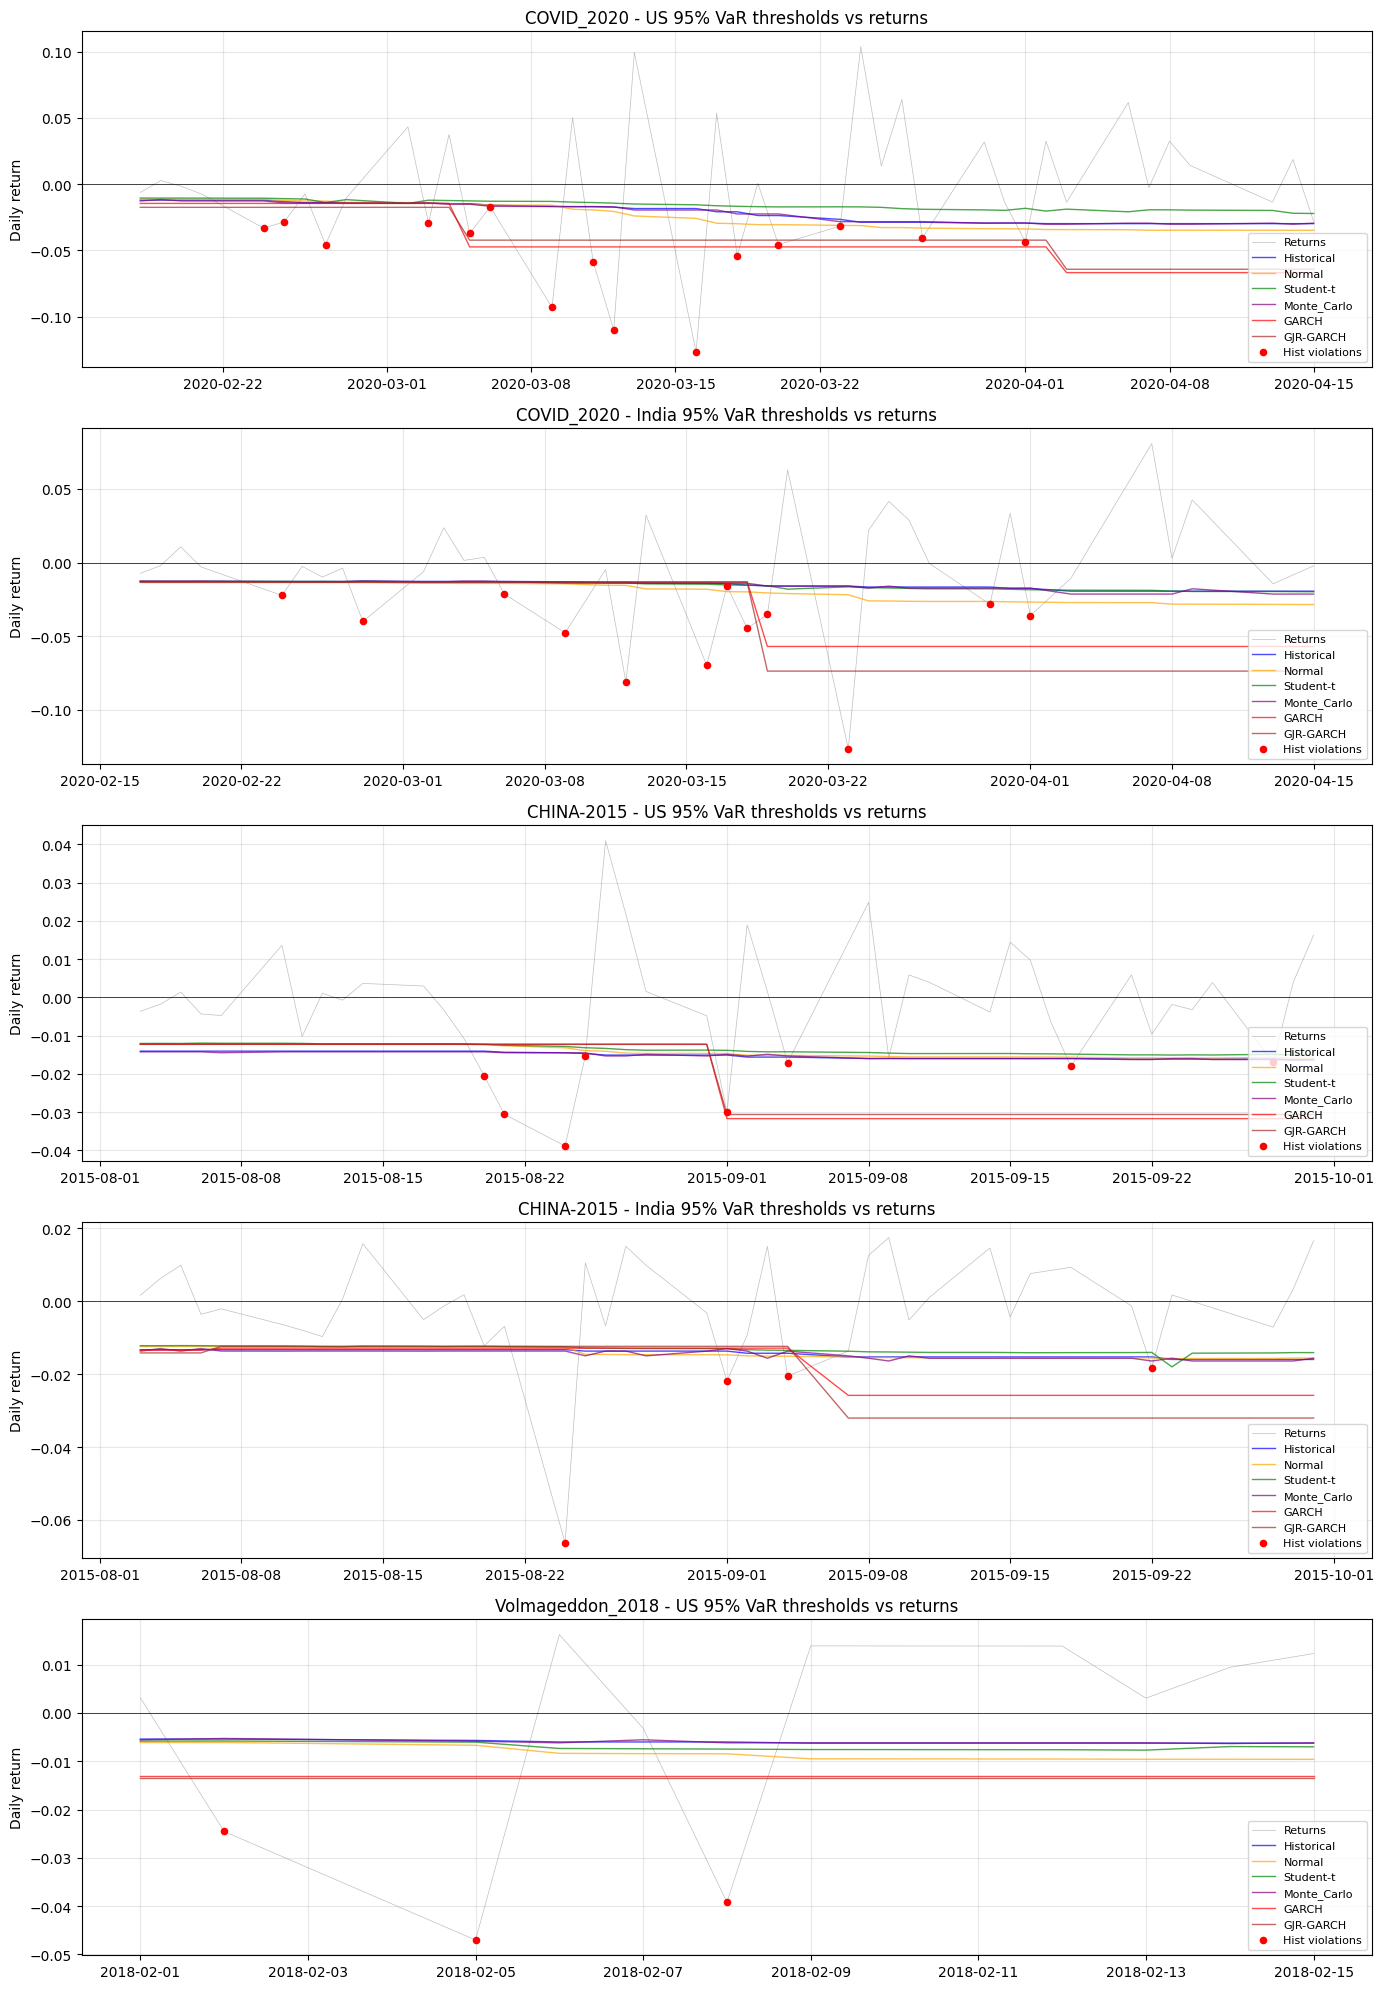

In [5]:
plot_cases = []
for window_name, (start, end, scope) in STRESS_WINDOWS.items():
    if scope == "US":
        markets = ["US"]
    else:
        markets = ["US", "India"]
    for market in markets:
        plot_cases.append((window_name, market, start, end))

fig, axes = plt.subplots(len(plot_cases), 1, figsize=(14, 4 * len(plot_cases)))
if len(plot_cases) == 1:
    axes = [axes]

colors = {
    "Historical": "blue",
    "Normal": "orange",
    "Student-t": "green",
    "Monte_Carlo": "purple",
    "GARCH": "red",
    "GJR-GARCH": "brown",
}

for ax, (window_name, market, start, end) in zip(axes, plot_cases):
    ret = returns_data[market]
    ret_window = ret.loc[pd.to_datetime(start):pd.to_datetime(end)]
    
    ax.plot(ret_window.index, ret_window, color="gray", linewidth=0.5, alpha=0.5, label="Returns")
    
    for method, var_series in var_data[market]["95%"].items():
        var_window = var_series.loc[pd.to_datetime(start):pd.to_datetime(end)]
        ax.plot(var_window.index, -var_window, color=colors[method], linewidth=1, alpha=0.7, label=method)
    
    hist_var = var_data[market]["95%"]["Historical"]
    aligned = pd.concat([ret_window, hist_var.loc[pd.to_datetime(start):pd.to_datetime(end)]], axis=1).dropna()
    aligned.columns = ["ret", "var"]
    violations = aligned["ret"] < -aligned["var"]
    if violations.any():
        viol_dates = aligned[violations].index
        ax.scatter(viol_dates, aligned.loc[viol_dates, "ret"], color="red", s=20, zorder=5, label="Hist violations")
    
    ax.set_title(f"{window_name} - {market} 95% VaR thresholds vs returns")
    ax.set_ylabel("Daily return")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.3)
    ax.axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

In [6]:
shock_results = []
for market in ["US", "India"]:
    for level in ["95%", "99%"]:
        for method, var_series in var_data[market][level].items():
            most_recent_var = var_series.iloc[-1]
            breach_ratio = abs(HYPOTHETICAL_SHOCK) / most_recent_var
            shock_results.append({
                "market": market,
                "level": level,
                "method": method,
                "var_today": most_recent_var,
                "breach_ratio": breach_ratio,
            })

shock_df = pd.DataFrame(shock_results)
shock_pivot = shock_df.pivot_table(
    index=["market", "level"],
    columns="method",
    values="breach_ratio",
)

print(f"Hypothetical shock: {HYPOTHETICAL_SHOCK * 100:.1f}% return")
print()
print("Breach ratio (actual loss / VaR):")
print(shock_pivot.round(2))

Hypothetical shock: -10.0% return

Breach ratio (actual loss / VaR):
method        GARCH  GJR-GARCH  Historical  Monte_Carlo  Normal  Student-t
market level                                                              
India  95%    10.24       9.84        9.32         9.49    8.37       7.30
       99%     7.24       6.96        5.27         5.81    5.87       3.32
US     95%     9.32       9.79        7.62         7.47    6.46       8.57
       99%     6.59       6.92        3.60         3.13    4.50       4.30


In [7]:
stress_results.to_csv(PROCESSED_DATA_DIR / "stress_test_summary.csv", index=False)
print("Saved stress_test_summary.csv")

Saved stress_test_summary.csv
